# Summary of mapping data

In this notebook we summarize and filter the barcode-promoter mapping and compile everything into a table.

In [21]:
from glob import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import regseq2

regseq2.viz.matplotlib_style()

We import the file names for all promoters (which are in the file names). The. first file is removed, as it contains all the sequenced variants that could not be matched to a promoter.

In [2]:
files = np.sort(glob("../../data/barcode_map/*.txt"))[1:]

Now we import each file and filter out any pairs of barcodes and promoter variants that have less than two reads, to make sure we remove any sequencing errors that made it past quality control.

In [3]:
df_list = []

for file in files:
    df = pd.read_csv(file, names=['promoter', 'barcode', 'count', 'name'])
    df = df[df['count'] > 2]
    df_list.append(df)

Barcodes need to me unique to a promoter variant. So here we filter out any barcodes that map to more than one promoter variant and only keep unique barcodes.

In [ ]:
df_map = pd.concat(df_list)
df_final = df_map[~df_map['barcode'].duplicated(keep=False)].copy()
df_final

## DicA binding site in dicC promoter

The promoter for dicC contains a binding site for DicA, which we can find by looking at the mutation rate across all sequenced promoter variants for the dicC promoter.


In [16]:
mut_mat = np.zeros([4, 160])
let_dict = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

for _, row in df_final[df_final['name'] == 'dicCp'].iterrows():
    for i, l in enumerate(row['promoter']):
        mut_mat[let_dict[l], i] += row['count']

In [17]:
mut_mat /= np.sum(mut_mat, axis=0)

In [20]:
mut_rate  = 1-np.max(mut_mat, axis=0)

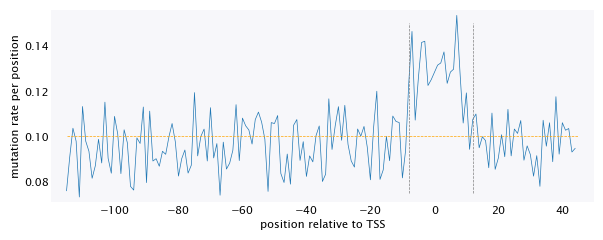

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.5))
ax.plot(np.arange(-115, 45), mut_rate)
ax.plot([-115, 45], [0.1, 0.1], ls='--', color='orange')
ax.vlines([-8, 12], ymin=0.075, ymax=0.15, ls='--', color='gray')

ax.set_xlabel('position relative to TSS')
ax.set_ylabel('mutation rate per position')

fig.savefig('pdf_files/dicC_mutation_rate.pdf')